In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
!pip install imbalanced-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 5.4 MB/s eta 0:00:00


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split
import joblib
import pickle
from sklearn.preprocessing import MinMaxScaler



from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (precision_recall_curve, classification_report,
                           ConfusionMatrixDisplay, balanced_accuracy_score,roc_curve,
                           PrecisionRecallDisplay, confusion_matrix,roc_auc_score,RocCurveDisplay)



import warnings
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd

# Chemin du fichier CSV extrait
csv_path = '/content/drive/MyDrive/ddos_nettoye.csv'  # (ou le chemin où il a été extrait)

# Lire le fichier CSV
data = pd.read_csv(csv_path)

# Afficher les premières lignes
data.head()

,Source Port,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Flow IAT Mean,Flow IAT Std,...,Fwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Average Packet Size,Avg Fwd Segment Size,Subflow Fwd Bytes,act_data_pkt_fwd,min_seg_size_forward,Label
0,60675,80,5220876,12,1928.0,509.0,0.0,160.666667,2.610438e+05,1.117421e+06,...,2.298465,0.0,1073.0,282.636364,296.095238,160.666667,1928,4,32,4
1,60676,80,12644252,5,0.0,0.0,0.0,0.000000,2.107375e+06,5.161910e+06,...,0.395437,0.0,0.0,0.000000,0.000000,0.000000,0,0,32,4
2,443,50458,3,2,0.0,0.0,0.0,0.000000,3.000000e+00,0.000000e+00,...,666666.666667,0.0,0.0,0.000000,0.000000,0.000000,0,0,20,0
3,443,50465,3,2,0.0,0.0,0.0,0.000000,3.000000e+00,0.000000e+00,...,666666.666667,0.0,0.0,0.000000,0.000000,0.000000,0,0,20,0
4,0,0,114329232,52,0.0,0.0,0.0,0.000000,2.241750e+06,4.083247e+06,...,0.454827,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0


# Refaire l'encodage binaire

In [7]:
# Convertir BENIGN=0, le reste=1
data['Label'] = np.where(data['Label'] == 0, 0, 1)  # Si Label == 0 → 0, sinon → 1

# Vérification
print(data['Label'].value_counts())

Label
1    48643451
0       56863
Name: count, dtype: int64


In [35]:
# Chemin de sauvegarde dans Colab (éphémère - sera perdu après déconnexion)
chemin = "/content/data.csv"

# Enregistrement du DataFrame en CSV
data.to_csv(chemin, index=False)  # index=False pour éviter d'enregistrer l'index

print(f"Fichier sauvegardé : {chemin}")

Fichier sauvegardé : /content/data.csv


# Separation train test

In [8]:
# Séparation avec 70% train / 30% test
X = data.drop('Label', axis=1)
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,  # 30% pour le test
    random_state=42,  # Reproductibilité
    stratify=y  # Maintient la proportion Attack/BENIGN dans les deux sets
)


In [9]:
print("Taille totale :", len(data))
print("Train set :", len(X_train), "| Test set :", len(X_test))
print("\nProportion 'BENIGN' (0) dans y_train :", y_train.mean())
print("Proportion 'BENIGN' (0) dans y_test :", y_test.mean())


Taille totale : 48700314
Train set : 34090219 | Test set : 14610095

Proportion 'BENIGN' (0) dans y_train : 0.9988323923645078
Proportion 'BENIGN' (0) dans y_test : 0.9988323826778676


In [10]:
print("\nDistribution des labels dans y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution des labels dans y_test:")
print(y_test.value_counts(normalize=True))


Distribution des labels dans y_train:
Label
1    0.998832
0    0.001168
Name: proportion, dtype: float64

Distribution des labels dans y_test:
Label
1    0.998832
0    0.001168
Name: proportion, dtype: float64


In [11]:
X_train.info()
X_test.info()
y_train.info()
y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34090219 entries, 16135442 to 36912278
Data columns (total 27 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  int64  
 1   Destination Port             int64  
 2   Flow Duration                int64  
 3   Total Fwd Packets            int64  
 4   Total Length of Fwd Packets  float64
 5   Fwd Packet Length Max        float64
 6   Fwd Packet Length Min        float64
 7   Fwd Packet Length Mean       float64
 8   Flow IAT Mean                float64
 9   Flow IAT Std                 float64
 10  Flow IAT Max                 float64
 11  Flow IAT Min                 float64
 12  Fwd IAT Total                float64
 13  Fwd IAT Mean                 float64
 14  Fwd IAT Std                  float64
 15  Fwd IAT Max                  float64
 16  Fwd IAT Min                  float64
 17  Fwd Header Length            int64  
 18  Fwd Packets/s                float64
 

# Feature scaling

In [12]:
# Comparaison des max entre train et test
print("Max (Train):", X_train.max())
print("Max (Test):", X_test.max())

Max (Train): Source Port                    6.553400e+04
Destination Port               6.553500e+04
Flow Duration                  1.200000e+08
Total Fwd Packets              1.001480e+05
Total Length of Fwd Packets    1.526642e+07
Fwd Packet Length Max          3.212000e+04
Fwd Packet Length Min          2.020000e+03
Fwd Packet Length Mean         3.015291e+03
Flow IAT Mean                  6.553614e+07
Flow IAT Std                   6.736895e+07
Flow IAT Max                   1.199544e+08
Flow IAT Min                   6.553614e+07
Fwd IAT Total                  1.200000e+08
Fwd IAT Mean                   6.553614e+07
Fwd IAT Std                    6.736895e+07
Fwd IAT Max                    1.199544e+08
Fwd IAT Min                    6.553614e+07
Fwd Header Length              1.559380e+05
Fwd Packets/s                  4.000000e+06
Min Packet Length              1.472000e+03
Max Packet Length              3.796000e+04
Packet Length Mean             4.023945e+03
Average Packet Size

In [13]:
# Colonnes où le test dépasse le train
test_higher = X_test.max() > X_train.max()
print("Colonnes avec max(test) > max(train):\n", test_higher[test_higher].index.tolist())

Colonnes avec max(test) > max(train):
 ['Fwd Packet Length Min', 'Flow IAT Std']


In [14]:
# Colonnes problématiques
problem_cols = ['Fwd Packet Length Min', 'Flow IAT Std']

# 1. Calculer les min/max globaux (train + test)
global_min = np.minimum(X_train.min(), X_test.min())
global_max = np.maximum(X_train.max(), X_test.max())

# 2. Initialiser le MinMaxScaler avec ces valeurs
scaler = MinMaxScaler()
scaler.fit(X_train)  # Initialisation standard

# 3. Forcer les min/max globaux pour les colonnes problématiques
scaler.data_min_[X_train.columns.get_indexer(problem_cols)] = global_min[problem_cols].values
scaler.data_max_[X_train.columns.get_indexer(problem_cols)] = global_max[problem_cols].values

# 4. Normalisation
X_train_normalized = scaler.transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [15]:
# Correction finale (au cas où)
X_test_normalized = np.clip(X_test_normalized, 0.0, 1.0)

# Vérification
print("Test - Valeurs > 1.0 :", np.any(X_test_normalized > 1.0))  # Doit être False
print("Max globaux utilisés :", scaler.data_max_[X_train.columns.get_indexer(problem_cols)])

Test - Valeurs > 1.0 : False
Max globaux utilisés : [2.02100000e+03 6.80829254e+07]


In [16]:
print("Train - Statistiques après normalisation:")
print(pd.DataFrame(X_train_normalized, columns=X_train.columns).describe())
print("\nTest - Statistiques après normalisation:")
print(pd.DataFrame(X_test_normalized, columns=X_test.columns).describe())

Train - Statistiques après normalisation:
        Source Port  Destination Port  Flow Duration  Total Fwd Packets  \
count  3.409022e+07      3.409022e+07   3.409022e+07       3.409022e+07   
mean   4.968842e-01      5.010200e-01   9.631982e-03       4.087742e-05   
std    4.194827e-01      2.884934e-01   4.655156e-02       2.518893e-03   
min    0.000000e+00      0.000000e+00   0.000000e+00       0.000000e+00   
25%    1.283303e-02      2.516365e-01   8.333333e-09       9.985322e-06   
50%    5.818659e-01      5.011673e-01   1.666667e-08       9.985322e-06   
75%    9.533677e-01      7.510185e-01   9.078833e-04       2.995596e-05   
max    1.000000e+00      1.000000e+00   1.000000e+00       1.000000e+00   

       Total Length of Fwd Packets  Fwd Packet Length Max  \
count                 3.409022e+07           3.409022e+07   
mean                  1.593178e-04           2.128862e-02   
std                   4.424665e-04           1.420118e-02   
min                   0.000000e+00    

# Sampling

In [17]:
# --- 1. Split supplémentaire pour l'optimisation du seuil ---
X_train_base, X_val, y_train_base, y_val = train_test_split(
    X_train_normalized, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [26]:
X_train_base.shape

(27272175, 27)

In [27]:
y_train_base.shape

(27272175,)

In [28]:
X_val.shape

(6818044, 27)

In [29]:
y_val.shape

(6818044,)

In [21]:
# --- 2. SMOTE appliqué uniquement sur le train de base ---
smote = SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_base, y_train_base)


In [30]:
X_train_resampled.shape

(29964365, 27)

In [31]:
y_train_resampled.shape

(29964365,)

In [33]:
# Avant SMOTE
print("Distribution avant SMOTE :")
print(y_train_base.value_counts())

# Après SMOTE
print("\nDistribution après SMOTE :")
print(pd.Series(y_train_resampled).value_counts())

Distribution avant SMOTE :
Label
1    27240332
0       31843
Name: count, dtype: int64

Distribution après SMOTE :
Label
1    27240332
0     2724033
Name: count, dtype: int64


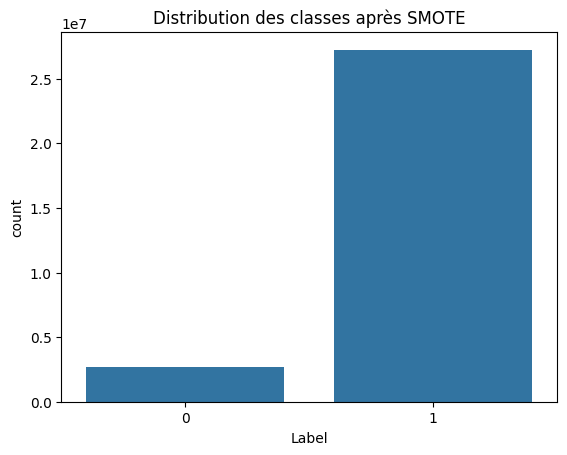

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution après SMOTE
sns.countplot(x=y_train_resampled)
plt.title("Distribution des classes après SMOTE")
plt.show()

# Random forest

In [22]:
# --- 3. Entraînement sur données rééquilibrées ---
model = RandomForestClassifier(
    class_weight={0: 1, 1: 1},
    max_depth=15,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight={0: 1, 1: 1}, max_depth=15, n_jobs=-1,
                       random_state=42)

In [23]:
# --- 4. Optimisation du seuil sur le validation set (non rééquilibré) ---
y_proba_val = model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_proba_val, pos_label=1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

In [24]:
# --- 5. Évaluation finale sur le test set ---
y_proba_test = model.predict_proba(X_test_normalized)[:, 1]
y_pred_test = (y_proba_test > optimal_threshold).astype(int)


In [25]:
import os
# --- Chemin principal ---
save_path = "/content/drive/MyDrive/model_results/"  # Chemin dans Drive
os.makedirs(save_path, exist_ok=True)

Seuil auto-optimisé: 0.216

Classification Report:
               precision    recall  f1-score   support

      BENIGN       0.99      1.00      0.99     17059
      Attack       1.00      1.00      1.00  14593036

    accuracy                           1.00  14610095
   macro avg       0.99      1.00      1.00  14610095
weighted avg       1.00      1.00      1.00  14610095



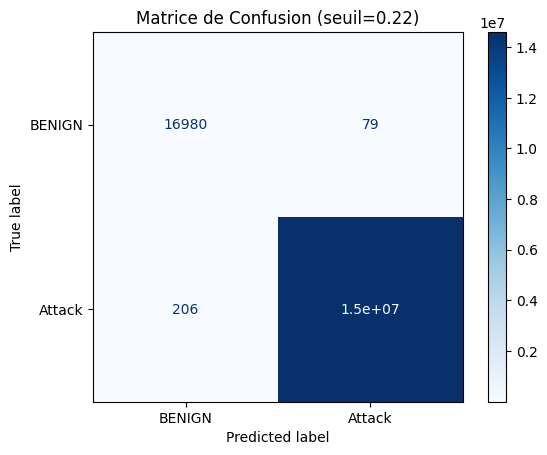

Taux de faux positifs (FPR): 0.46%

Balanced Accuracy: 0.9976774485508328

AUC-ROC: 0.9999994569892842


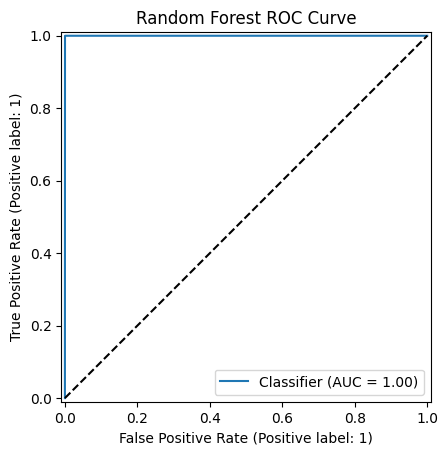


✅ Modèle Random Forest et résultats sauvegardés avec succès.


In [32]:
# --- 6. Résultats ---
result_text = ""

# Seuil auto-optimisé
print(f"Seuil auto-optimisé: {optimal_threshold:.3f}")
result_text += f"Seuil auto-optimisé: {optimal_threshold:.3f}\n\n"

# Rapport complet
report = classification_report(y_test, y_pred_test, target_names=["BENIGN", "Attack"])
print("\nClassification Report:\n", report)
result_text += "Classification Report:\n" + report + "\n\n"

# Matrice de confusion
cm_display = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=["BENIGN", "Attack"],
    cmap='Blues'
)
plt.title(f"Matrice de Confusion (seuil={optimal_threshold:.2f})")
plt.savefig(f"{save_path}/ddos_v2_RandomForest_confusion_matrix.png")  # Sauvegarde
plt.show()  # ➔ Affiche aussi dans le notebook

# Calcul de la matrice de confusion pour extraire le nombre de Faux Positifs (FP) et Vrais Négatifs (TN)
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

# Calcul du taux de faux positifs
fpr = fp / (fp + tn)
print(f"Taux de faux positifs (FPR): {fpr* 100:.2f}%")
result_text += f"Taux de faux positifs (FPR): {fpr* 100:.2f}%\n\n"

# Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred_test)
print("\nBalanced Accuracy:", balanced_acc)
result_text += f"Balanced Accuracy: {balanced_acc:.6f}\n\n"

# --- AUC-ROC ---
auc_score = roc_auc_score(y_test, y_proba_test)
print("\nAUC-ROC:", auc_score)
result_text += f"AUC-ROC: {auc_score:.6f}\n\n"

# Courbe ROC
roc_display = RocCurveDisplay.from_predictions(y_test, y_proba_test)
plt.title("Random Forest ROC Curve")
plt.plot([0, 1], [0, 1], 'k--')  # Ajouter la diagonale hasard
plt.savefig(f"{save_path}/ddos_v2_RandomForest_ROC_curve.png")  # Sauvegarde
plt.show()  # ➔ Affiche aussi dans le notebook

# --- 7. Sauvegarder modèle + résultats ---

# Modèle
with open(f"{save_path}/ddos_v2_RandomForest_model.pkl", "wb") as model_file:
    pickle.dump(model, model_file)

# Résultats
with open(f"{save_path}/ddos_v2_RandomForest_results.txt", "w", encoding="utf-8") as result_file:
    result_file.write(result_text)

print("\n✅ Modèle Random Forest et résultats sauvegardés avec succès.")